In [1]:
# Starting the Regression
# import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("../data/BCF_training.csv")  # Load your dataset here

In [4]:
df.head()

,CAS,SMILES,Experimental value [log(L/kg)],NumAromaticRings,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,fr_COO,fr_COO2,fr_halogen,MolWt,MolLogP
0,50-29-3,c1cc(ccc1C(c2ccc(cc2)Cl)C(Cl)(Cl)Cl)Cl,3.605,2,0,5,2,100,0.540334,0.00,85.0370,2.474117,494.044161,0,0,5,354.491,6.4955
1,50-30-6,O=C(O)c1c(cccc1Cl)Cl,-0.222,1,1,4,1,58,0.740184,37.30,43.4213,3.318913,276.242090,1,1,2,191.013,2.6916
2,50-31-7,O=C(O)c1c(ccc(c1Cl)Cl)Cl,0.073,1,1,5,1,64,0.744344,37.30,48.4313,3.428931,335.668528,1,1,3,225.458,3.3450
3,50-32-8,c1ccc2c(c1)cc3ccc4cccc5ccc2c3c45,2.731,5,0,0,0,92,0.243454,0.00,87.6520,2.230840,1069.721887,0,0,0,252.316,5.7372
4,51-28-5,O=[N+]([O-])c1ccc(O)c(c1)[N+](=O)[O-],0.052,1,5,7,2,68,0.548520,106.51,41.4156,3.267052,375.287402,0,0,0,184.107,1.2086


In [6]:
df.columns.to_list()

['CAS',
 'SMILES',
 'Experimental value [log(L/kg)]',
 'NumAromaticRings',
 'NumHAcceptors',
 'NumHeteroatoms',
 'NumRotatableBonds',
 'NumValenceElectrons',
 'qed',
 'TPSA',
 'MolMR',
 'BalabanJ',
 'BertzCT',
 'fr_COO',
 'fr_COO2',
 'fr_halogen',
 'MolWt',
 'MolLogP']

In [7]:
df.shape

(800, 18)

In [9]:
df.isnull().sum()

CAS                               0
SMILES                            0
Experimental value [log(L/kg)]    0
NumAromaticRings                  0
NumHAcceptors                     0
NumHeteroatoms                    0
NumRotatableBonds                 0
NumValenceElectrons               0
qed                               0
TPSA                              0
MolMR                             0
BalabanJ                          0
BertzCT                           0
fr_COO                            0
fr_COO2                           0
fr_halogen                        0
MolWt                             0
MolLogP                           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Experimental value [log(L/kg)],800.0,1.792558,1.332112,-1.700000,0.660750,1.754500,2.812250,5.694000
NumAromaticRings,800.0,1.282500,1.059054,0.000000,1.000000,1.000000,2.000000,7.000000
NumHAcceptors,800.0,2.281250,2.386266,0.000000,1.000000,2.000000,4.000000,20.000000
NumHeteroatoms,800.0,4.265000,3.500013,0.000000,2.000000,4.000000,6.000000,30.000000
NumRotatableBonds,800.0,2.981250,4.017907,0.000000,0.000000,2.000000,4.000000,35.000000
NumValenceElectrons,800.0,84.520000,41.604967,16.000000,56.000000,76.000000,102.500000,342.000000
qed,800.0,0.560874,0.161189,0.036370,0.466675,0.560545,0.664651,0.941210
TPSA,800.0,37.034150,40.486996,0.000000,3.240000,27.690000,54.860000,399.910000
MolMR,800.0,64.191477,29.382869,16.573000,42.495000,60.029150,77.723625,278.243000
BalabanJ,800.0,2.760433,0.704267,1.064135,2.280729,2.740037,3.151898,8.210941


In [12]:
df['Experimental value [log(L/kg)]'].describe()

count    800.000000
mean       1.792558
std        1.332112
min       -1.700000
25%        0.660750
50%        1.754500
75%        2.812250
max        5.694000
Name: Experimental value [log(L/kg)], dtype: float64

<Axes: >

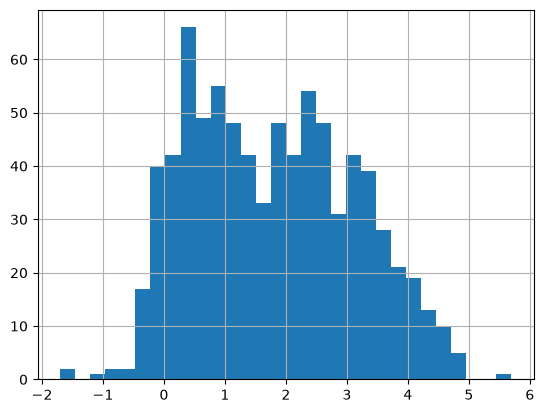

In [13]:
df['Experimental value [log(L/kg)]'].hist(bins=30)

In [14]:
df.groupby(df['Experimental value [log(L/kg)]'] > 2)['fr_halogen'].mean()

Experimental value [log(L/kg)]
False    0.911504
True     1.948276
Name: fr_halogen, dtype: float64

In [15]:
df[df['Experimental value [log(L/kg)]'] < -1]


,CAS,SMILES,Experimental value [log(L/kg)],NumAromaticRings,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,fr_COO,fr_COO2,fr_halogen,MolWt,MolLogP
624,01/02/1918,O=C(O)c1nc(c(c(N)c1Cl)Cl)Cl,-1.700,1,3,7,1,70,0.739877,76.21,50.6387,3.497381,380.632381,1,1,3,241.461,2.3222
707,30560-19-1,O=C(NP(=O)(OC)SC)C,-1.523,0,4,6,3,60,0.668589,55.40,41.9472,4.074119,163.885639,0,0,0,183.169,1.2400


In [16]:
df.groupby(df['Experimental value [log(L/kg)]'] > 2)[['fr_COO', 'fr_COO2']].mean()

,fr_COO,fr_COO2
Experimental value [log(L/kg)],,
False,0.123894,0.123894
True,0.002874,0.002874
